In [1]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import torch
import torchsde
from torchdyn.core import NeuralODE
from torchvision import datasets, transforms
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models.unet import UNetModel

savedir = "models/mnist"
os.makedirs(savedir, exist_ok=True)

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
batch_size = 64
epochs = 3

trainset = datasets.MNIST(
    "../data",
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]),
)

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, drop_last=True
)


In [7]:
sigma = 0.0
model = UNetModel(dim=(1,28,28), num_channels=32,num_res_blocks=1).to(device)
optimizer = torch.optim.AdamW(model.parameters())
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", rtol=1e-4, atol=1e-4)


In [8]:
for i in range(epochs):
    for i, data in tqdm(enumerate(train_loader)):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        x0 = torch.rand_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model (t, xt)

        loss = torch.mean((vt - ut) **2)
        loss.backward()
        optimizer.step()
        

937it [03:50,  4.06it/s]
937it [04:17,  3.64it/s]
937it [04:20,  3.59it/s]


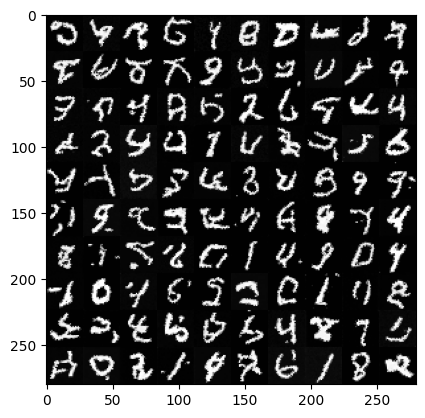

In [10]:
with torch.no_grad():
    traj = node.trajectory(
        torch.rand(100, 1, 28, 28, device=device),
        t_span=torch.linspace(0, 1, 2, device=device)
    )
grid = make_grid(traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10)  
img = ToPILImage()(grid)
plt.imshow(img)  